In [1]:
%pip install pygad

Note: you may need to restart the kernel to use updated packages.


Initial guess [-1, 1], Result: [0.99999551 0.99999101], Value: 2.0172579078957455e-11, Success: True, Iterations: 31, Time: 0.0103 sec
Initial guess [2, 2], Result: [0.99999565 0.99999129], Value: 1.8932681887175893e-11, Success: True, Iterations: 30, Time: 0.0091 sec
Initial guess [0, 0], Result: [0.99999467 0.99998932], Value: 2.8439990629105454e-11, Success: True, Iterations: 19, Time: 0.0072 sec
PyGAD initial guess [-1, 1], Solution: [1.01375443 1.02771469], Value: rosenbrock(solution), iterations: 2000, Time: 1.2186 sec
PyGAD initial guess [2, 2], Solution: [0.99326783 0.98599486], Value: rosenbrock(solution), iterations: 2000, Time: 1.2164 sec
PyGAD initial guess [0, 0], Solution: [1.02819981 1.05741579], Value: rosenbrock(solution), iterations: 2000, Time: 1.0916 sec


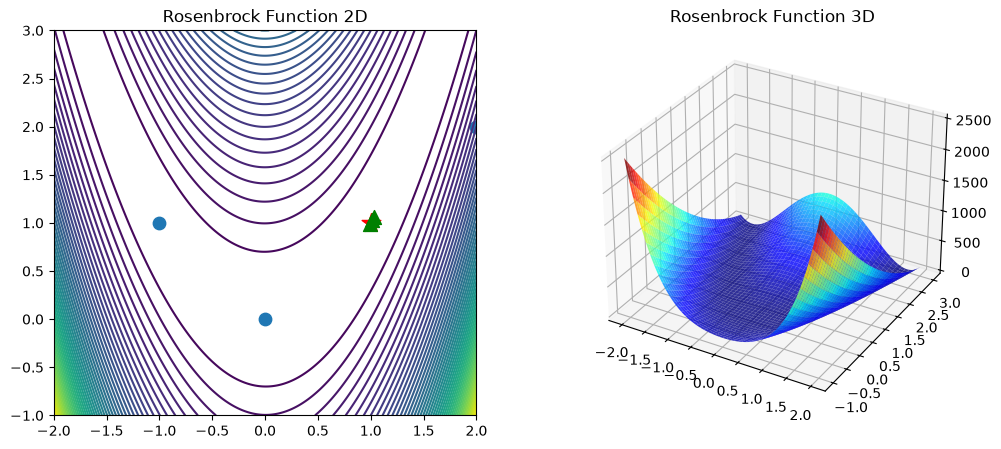

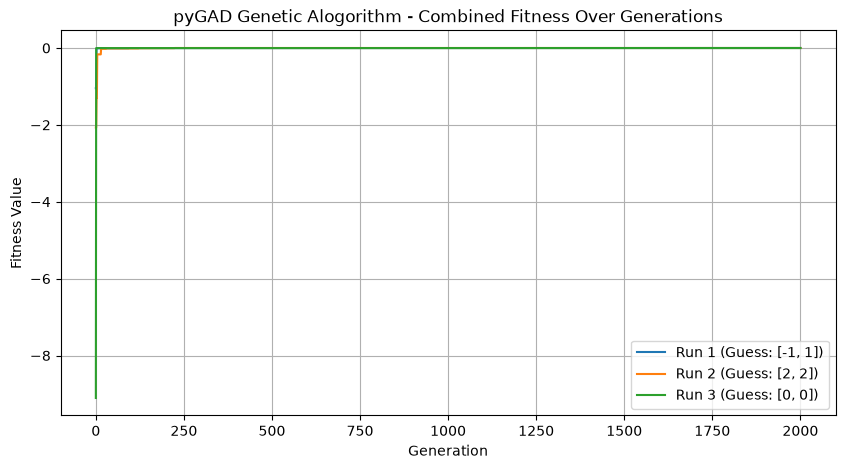

<Figure size 640x480 with 0 Axes>

In [5]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
import pygad

# Define Rosenbrock function
def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

# 2D & 3D plots
x_range = np.linspace(-2, 2, 400)
y_range = np.linspace(-1, 3, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = rosenbrock([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Rosenbrock Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Rosenbrock Function 3D")


elapsed_time = []
# Scipy Optimization
init_guesses = [[-1, 1], [2, 2], [0, 0]]
initial_points = np.array(init_guesses)
ax1.scatter(
    initial_points[:, 0],
    initial_points[:, 1],
    marker='o',
    s=80,
    label='Initial Guess'
)
for guess in init_guesses:
    start_time = time.perf_counter()   # start timer
    result = minimize(rosenbrock, guess, method='BFGS')
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time: {elapsed_time:.4f} sec")
ax1.scatter(result.x[0], result.x[1], marker='*', s=200, color='red', label='SCIPY Result')
fig_fitness = plt.figure(figsize=(10,5))
# PyGAD Optimization
def fitness_func(ga_instance, solution, solution_idx):
    return -rosenbrock(solution) # pygad maximizes, so negate

elapsed_time = []
for idx, guess in enumerate(init_guesses):
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=2000,
                           sol_per_pop=20,
                           num_genes=2,
                           num_parents_mating=8,
                           fitness_func=fitness_func,
                           init_range_low=-2,
                           init_range_high=2,
                           gene_space={'low':-2, 'high':2})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()     # end timer
    elapsed_time = end_time - start_time
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: rosenbrock(solution), iterations: {iters}, Time: {elapsed_time:.4f} sec")
    ax1.scatter(solution[0], solution[1], marker='^', s=100, color='green', label='PyGAD Result')
    fitness_history = ga_instance.best_solutions_fitness
    plt.plot(fitness_history, label=f"Run {idx + 1} (Guess: {guess})")

plt.title("pyGAD Genetic Alogorithm - Combined Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness Value")
plt.legend()
plt.grid(True)
plt.show()

ax1.scatter(
    1,
    1,
    marker='X',
    s=150,
    label='Global Minimum (1,1)'
)
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()




Iterations: SciPy BFGS converges in fewer iterations, whereas PyGAD requires many generations to reach the minimum.
Time taken: SciPy is generally faster because BFGS uses gradient-based optimization, while PyGAD evaluates a population of solutions.
Solution: Both methods give a solution close to \((1,1)\) with function value close to 0.
Accuracy: For the same decimal-point accuracy, SciPy generally achieves the required accuracy more efficiently.
Overall: SciPy performs better in terms of iterations and computational time, while PyGAD provides a global population-based search.
Conclusion: For the Rosenbrock function, SciPy BFGS is more efficient, while PyGAD is useful when gradient information is unavailable.

Initial guess [0, 0], Result: [ 9.99999966e-01 -1.64047755e-08], Value: 5.950412924404877e-15, Success: True, Iterations: 3, Time taken: 0.0015 seconds
Initial guess [-4, 4], Result: [1.00000002e+00 5.98350409e-08], Value: 5.2197810463598925e-15, Success: True, Iterations: 18, Time taken: 0.0054 seconds
Initial guess [4, 0], Result: [1.00000001e+00 3.95264636e-07], Value: 1.566975197383418e-13, Success: True, Iterations: 10, Time taken: 0.0032 seconds
PyGAD initial guess [0, 0], Solution: [ 0.99659186 -0.00873152], Value: 0.00013312640257161622, Iterations: 300, Time taken: 0.2378 seconds
PyGAD initial guess [-4, 4], Solution: [ 0.99411938 -0.0124526 ], Value: 0.0003235508059741168, Iterations: 300, Time taken: 0.2651 seconds
PyGAD initial guess [4, 0], Solution: [1.00400798 0.00228321], Value: 8.587420371686206e-05, Iterations: 300, Time taken: 0.2567 seconds


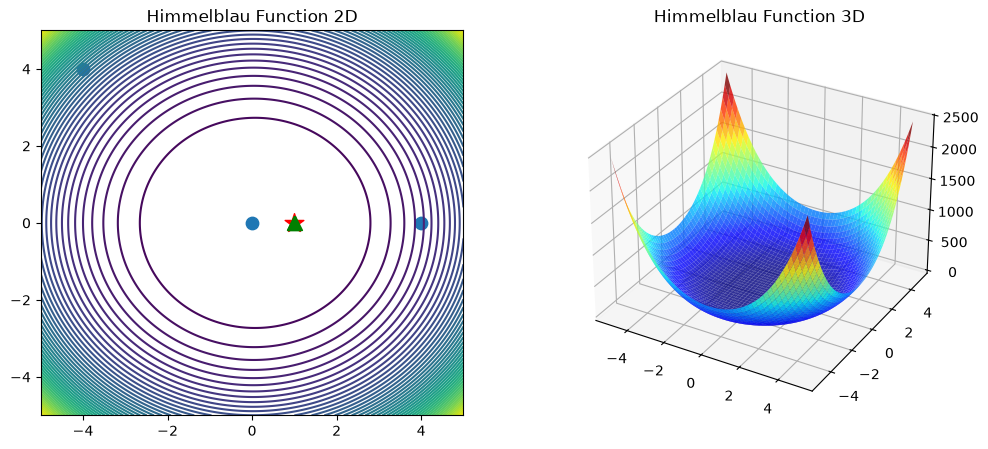

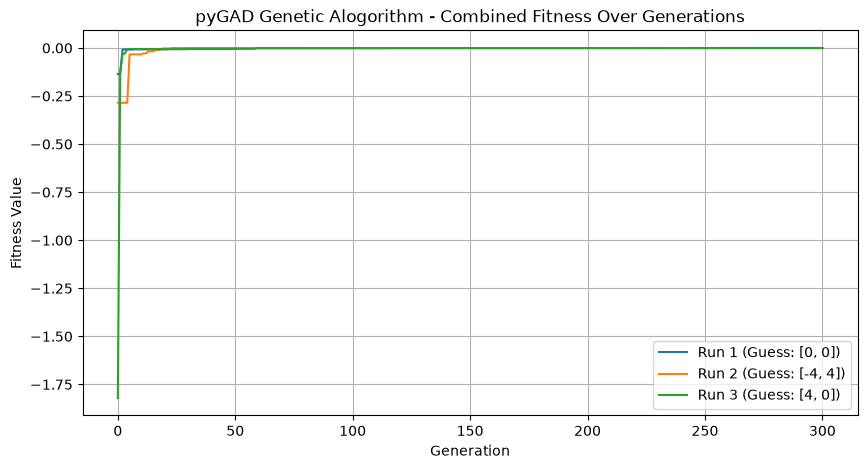

<Figure size 640x480 with 0 Axes>

In [21]:
def himmelblau(x):
    x = np.asarray(x) # Convert to numpy array
    return (x[0]**2 + x[1]**2 - 1)**2 + (x[0] - 1)**2 + (x[1])**2
    #return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

# 2D & 3D plots
x_range = np.linspace(-5, 5, 400)
y_range = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_range, y_range)
Z = himmelblau([X, Y])

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(121)
cp = ax1.contour(X, Y, Z, levels=50)
ax1.set_title("Himmelblau Function 2D")
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, Z, cmap='jet', alpha=0.8)
ax2.set_title("Himmelblau Function 3D")

elapsed_time = []
# Scipy Optimization
init_guesses = [[0, 0], [-4, 4], [4, 0]]
initial_points = np.array(init_guesses)
ax1.scatter(
    initial_points[:, 0],
    initial_points[:, 1],
    marker='o',
    s=80,
    label='Initial Guess'
)
for guess in init_guesses:
    start_time = time.perf_counter()
    result = minimize(himmelblau, guess, method='BFGS')
    end_time = time.perf_counter()
    elapsed_time.append(end_time - start_time)
    print(f"Initial guess {guess}, Result: {result.x}, Value: {result.fun}, Success: {result.success}, Iterations: {result.nit}, Time taken: {elapsed_time[-1]:.4f} seconds") 
ax1.scatter(result.x[0], result.x[1], marker='*', s=200, color='red', label='SCIPY Result' )   
# PyGAD Optimization
def fitness_func2(ga_instance, solution, solution_idx):
    return -himmelblau(solution)
elapsed_time =[]
plt.figure(figsize=(10,5))
for idx, guess in enumerate(init_guesses):
    start_time = time.perf_counter()   # start timer
    ga_instance = pygad.GA(num_generations=300,
                           sol_per_pop=30,
                           num_genes=2,
                           num_parents_mating=12,
                           fitness_func=fitness_func2,
                           init_range_low=-5,
                           init_range_high=5,
                           gene_space={'low':-5, 'high':5})
    ga_instance.run()
    solution, solution_fitness, _ = ga_instance.best_solution()
    iters = ga_instance.generations_completed
    end_time = time.perf_counter()   # end timer
    elapsed_time.append(end_time - start_time)
    print(f"PyGAD initial guess {guess}, Solution: {solution}, Value: {himmelblau(solution)}, Iterations: {iters}, Time taken: {elapsed_time[-1]:.4f} seconds")
    ax1.scatter(solution[0], solution[1], marker='^', s=100, color='green', label='PyGAD Result')
    fitness_history = ga_instance.best_solutions_fitness
    plt.plot(fitness_history, label=f"Run {len(elapsed_time)} (Guess: {guess})")

plt.title("pyGAD Genetic Alogorithm - Combined Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Fitness Value")
plt.legend()
plt.grid(True)
plt.show()

ax1.scatter(
    1,
    0,
    marker='X',
    s=150,
    color='black',
    label='Global Minimum (1,0)'
)

ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()
# ga_instance.plot_fitness()

Different initial guesses produce different solutions because the function has multiple minima.
SciPy BFGS converges quickly to a nearby minimum depending on the starting point.
PyGAD searches the entire range and can identify the global minimum without using gradients.
The 2D contour and 3D surface plots help visualize the multiple minima of the function.
Both methods can obtain a minimum with function value close to 0.
Overall, SciPy is faster, while PyGAD provides a population-based global search